# Control design

In [1]:
from nbsetup import *
from pipeline import Datos, UnidadesTratadas, comparar

In [2]:
datos = Datos()
base = UnidadesTratadas(datos, radio_m=300)   # especificación principal

## La restricción y la construcción

Un control no puede traslaparse con ninguna área tratada. Como las unidades son
círculos del mismo radio y los centros son fijos entre radios, eso se traduce en
**600 m mínimo entre el centro de un control y el de cualquier tratada**: dos
veces el radio más grande.

Los centros candidatos son **puntos aleatorios sobre la red vial**. De las cuatro
construcciones que consideramos es la que menos decisiones arrastra: no hay que
definir qué cuenta como intersección ni dónde empieza una rejilla, y cubre tanto
tramos como cruces porque unos y otros son parte de la red. La semilla es
parámetro, así que repetir con otra es una prueba de robustez directa.

La restricción de **600 m entre controles** no se aplica aquí. Solo importa
entre los controles que terminen emparejados; filtrarla desde el pool dejaría
unos cientos de candidatos en vez de decenas de miles y empeoraría el pareo sin
necesidad.

In [3]:
SEMILLA = 0
RADIO = 300
SEPARACION_TRATADA = 2 * RADIO   # traslape cero con cualquier tratada

# las jerarquías elegibles salen de dónde están las cámaras, no las fijo yo:
# un control en una vía donde el programa nunca habría puesto cámara no es
# contrafactual, es ruido
tipos_con_camara = (
    gpd.sjoin_nearest(datos.camaras[["geometry"]], datos.vialidades[["TIPO_VIA", "geometry"]])
    .TIPO_VIA.unique()
)
vias = datos.vialidades[datos.vialidades.TIPO_VIA.isin(tipos_con_camara)]

print("jerarquías con cámara:", sorted(tipos_con_camara))
print(f"segmentos elegibles: {len(vias):,} de {len(datos.vialidades):,}")
print(f"kilómetros elegibles: {vias.length.sum()/1000:,.0f}")

jerarquías con cámara: ['Vía de acceso controlado', 'Vía primaria']
segmentos elegibles: 10,503 de 10,503
kilómetros elegibles: 2,242


In [4]:
def sortear_centros(vias, n, semilla):
    """Puntos aleatorios sobre la red, proporcionales a la longitud de cada segmento.

    Sortear segmento y luego punto daría el mismo peso a un tramo de 20 m que a
    uno de 2 km. Acumulando longitudes, cada metro de vía tiene la misma
    probabilidad de recibir un centro.
    """
    acumulada = np.cumsum(vias.length.values)
    sorteo = np.random.default_rng(semilla).uniform(0, acumulada[-1], n)

    indice = np.searchsorted(acumulada, sorteo)
    offset = sorteo - np.concatenate([[0], acumulada])[indice]
    puntos = [vias.geometry.values[i].interpolate(d) for i, d in zip(indice, offset)]

    return gpd.GeoDataFrame(
        vias.iloc[indice][["ID_VIA", "NOMBRE", "TIPO_VIA", "CARRILES", "CIRCULA", "NIVEL"]]
        .reset_index(drop=True),
        geometry=puntos,
        crs=vias.crs,
    )


candidatos = sortear_centros(vias, n=20_000, semilla=SEMILLA)
candidatos.head(3)

,ID_VIA,NOMBRE,TIPO_VIA,CARRILES,CIRCULA,NIVEL,geometry
0,50,Ruta 05,Vía primaria,2,Un sentido,0,POINT (2808111.666 829736.827)
1,11,Viaducto C,Vía de acceso controlado,2,Un sentido,-1,POINT (2789423.34 817907.67)
2,1,Circuito Interior,Vía de acceso controlado,3,Un sentido,0,POINT (2803801.068 824779.657)


In [13]:
# fuera los que se traslaparían con un área tratada
from scipy.spatial import cKDTree

centros_tratados = np.column_stack([base.centros.geometry.x, base.centros.geometry.y])
coordenadas = np.column_stack([candidatos.geometry.x, candidatos.geometry.y])

candidatos["dist_tratada_m"] = cKDTree(centros_tratados).query(coordenadas)[0]
controles = (
    candidatos[candidatos.dist_tratada_m >= SEPARACION_TRATADA]
    .reset_index(drop=True)
    .assign(control_id=lambda x: range(len(x)))
)

print(f"sorteados      : {len(candidatos):,}")
print(f"muy cerca      : {len(candidatos) - len(controles):,}")
print(f"pool de control: {len(controles):,}  ({len(controles)/len(base.unidades):.0f} por tratada)")

sorteados      : 20,000
muy cerca      : 5,344
pool de control: 14,656  (148 por tratada)


In [14]:
# la verificación que importa: ningún círculo de control puede tocar uno tratado
circulos_control = gpd.GeoDataFrame(
    controles.drop(columns="geometry"),
    geometry=controles.geometry.buffer(RADIO),
    crs=controles.crs,
)

cruces = gpd.sjoin(circulos_control, base.unidades[["unidad_id", "geometry"]], predicate="intersects")
print(f"controles que tocan un área tratada: {len(cruces)}   <- tiene que ser 0")
print(f"distancia mínima observada a una tratada: {controles.dist_tratada_m.min():,.0f} m")

controles que tocan un área tratada: 0   <- tiene que ser 0
distancia mínima observada a una tratada: 600 m


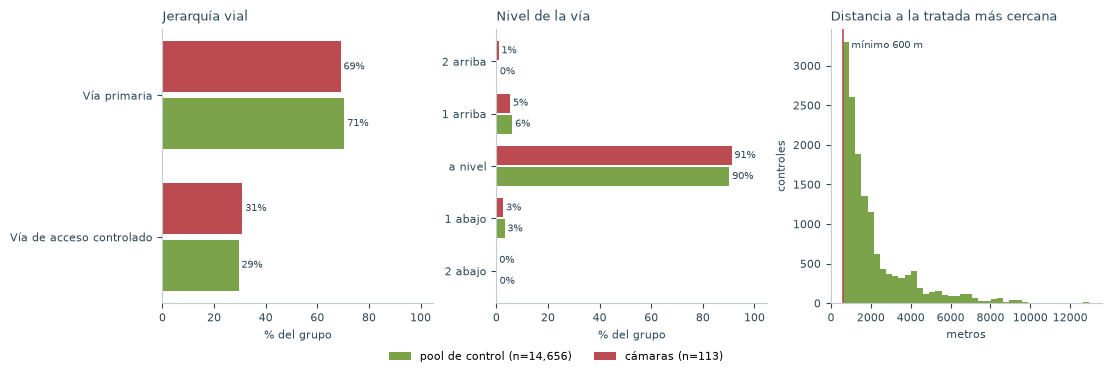

In [7]:
# composición del pool contra la de las cámaras, en porcentajes: las N son muy
# distintas (14,656 vs 113) así que comparar conteos no diría nada
CONTROL, TRATADA = "#7BA34A", "#BC4B51"   # validados: CVD ΔE 10.0 entre sí
TINTA = "#2F4858"

camaras_via = gpd.sjoin_nearest(
    datos.camaras[["geometry"]],
    datos.vialidades[["TIPO_VIA", "NIVEL", "geometry"]],
)

def compara(columna, orden=None):
    """Porcentaje de cada categoría en el pool y en las cámaras."""
    tabla = pd.DataFrame({
        "control": controles[columna].value_counts(normalize=True),
        "tratada": camaras_via[columna].value_counts(normalize=True),
    }).fillna(0) * 100
    return tabla.reindex(orden) if orden is not None else tabla.sort_values("control")


fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), layout="constrained")

# --- jerarquía vial
tabla = compara("TIPO_VIA")
y = np.arange(len(tabla))
for desplaza, columna, color, etiqueta in [
    (-0.2, "control", CONTROL, f"pool de control (n={len(controles):,})"),
    (0.2, "tratada", TRATADA, f"cámaras (n={len(camaras_via):,})"),
]:
    barras = axes[0].barh(y + desplaza, tabla[columna], height=0.36, color=color, label=etiqueta)
    axes[0].bar_label(barras, fmt="%.0f%%", padding=2, fontsize=7, color=TINTA)
axes[0].set_yticks(y, tabla.index)
axes[0].set_title("Jerarquía vial", fontsize=9, loc="left", color=TINTA)
axes[0].set_xlim(0, 105)

# --- nivel de la vía: ordenado, de subterráneo a elevado
orden = [-2, -1, 0, 1, 2]
etiquetas_nivel = {-2: "2 abajo", -1: "1 abajo", 0: "a nivel", 1: "1 arriba", 2: "2 arriba"}
tabla = compara("NIVEL", orden=orden).fillna(0)
y = np.arange(len(tabla))
for desplaza, columna, color in [(-0.2, "control", CONTROL), (0.2, "tratada", TRATADA)]:
    barras = axes[1].barh(y + desplaza, tabla[columna], height=0.36, color=color)
    axes[1].bar_label(barras, fmt="%.0f%%", padding=2, fontsize=7, color=TINTA)
axes[1].set_yticks(y, [etiquetas_nivel[n] for n in tabla.index])
axes[1].set_title("Nivel de la vía", fontsize=9, loc="left", color=TINTA)
axes[1].set_xlim(0, 105)

# --- distancia a la tratada más cercana
axes[2].hist(controles.dist_tratada_m, bins=40, color=CONTROL)
axes[2].axvline(SEPARACION_TRATADA, color=TRATADA, linewidth=1.2)
axes[2].annotate(
    f"mínimo {SEPARACION_TRATADA} m", xy=(SEPARACION_TRATADA, axes[2].get_ylim()[1]),
    xytext=(6, -8), textcoords="offset points", fontsize=7, color=TINTA, va="top",
)
axes[2].set_title("Distancia a la tratada más cercana", fontsize=9, loc="left", color=TINTA)
axes[2].set_xlabel("metros", fontsize=8, color=TINTA)
axes[2].set_ylabel("controles", fontsize=8, color=TINTA)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8, colors=TINTA)
    ax.spines[["left", "bottom"]].set_color("#C4CACE")
axes[0].set_xlabel("% del grupo", fontsize=8, color=TINTA)
axes[1].set_xlabel("% del grupo", fontsize=8, color=TINTA)

fig.legend(loc="lower center", ncols=2, frameon=False, fontsize=8, bbox_to_anchor=(.5, -.08))
plt.show()

In [8]:
# ¿cambia el pool con la semilla?
for semilla in (0, 1, 42):
    c = sortear_centros(vias, n=20_000, semilla=semilla)
    d = cKDTree(centros_tratados).query(np.column_stack([c.geometry.x, c.geometry.y]))[0]
    print(f"semilla {semilla:>2}: {(d >= SEPARACION_TRATADA).sum():,} controles | "
          f"mediana dist {np.median(d[d >= SEPARACION_TRATADA]):,.0f} m")

semilla  0: 14,656 controles | mediana dist 1,439 m
semilla  1: 14,629 controles | mediana dist 1,432 m
semilla 42: 14,662 controles | mediana dist 1,451 m


### Cuántos controles disjuntos caben

La restricción control-control se aplicará al final, sobre los emparejados. Pero
vale la pena saber cuántos controles sin traslape entre sí caben en la ciudad:
es el techo del tamaño de muestra si algún día se quisiera imponer desde el
principio.

In [9]:
def imponer_separacion(puntos, separacion_m, semilla=0):
    """Subconjunto donde ningún punto queda a menos de separacion_m de otro."""
    orden = np.random.default_rng(semilla).permutation(len(puntos))
    coords = np.column_stack([puntos.geometry.x.values, puntos.geometry.y.values])

    elegidos = []
    for i in orden:
        if elegidos and np.hypot(*(coords[elegidos] - coords[i]).T).min() < separacion_m:
            continue
        elegidos.append(i)

    return puntos.iloc[sorted(elegidos)]


disjuntos = imponer_separacion(controles, separacion_m=2 * RADIO, semilla=SEMILLA)
print(f"{len(controles):,} candidatos -> {len(disjuntos):,} controles disjuntos a {2*RADIO} m")
print(f"tratadas a emparejar: {len(base.unidades)}")

14,656 candidatos -> 631 controles disjuntos a 600 m
tratadas a emparejar: 99


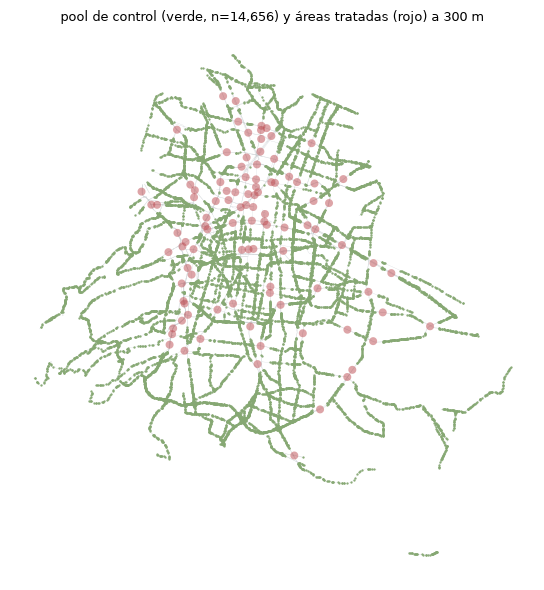

In [10]:
# dónde caen
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_axis_off()
datos.vialidades.plot(ax=ax, linewidth=.15, color="#C4CACE", zorder=1)
gpd.GeoSeries(controles.geometry, crs=controles.crs).plot(
    ax=ax, markersize=.4, color="#86A873", zorder=2
)
gpd.GeoSeries(base.unidades.geometry, crs=base.unidades.crs).plot(
    ax=ax, facecolor="#BC4B51", edgecolor="none", alpha=.5, zorder=3
)
ax.set_title(f"pool de control (verde, n={len(controles):,}) y áreas tratadas (rojo) a {RADIO} m", fontsize=9)
fig.tight_layout()
plt.show()